# Desafio 4 - Bot QA con LSTM (PyTorch)

Modelo encoder-decoder con LSTM en PyTorch para responder preguntas usando datos de ConvAI2.

**Objetivos:**
- Aplicar el modelo en PyTorch
- Extender el entrenamiento con mas datos y mayor longitud de secuencias
- Explorar el impacto de la cantidad de neuronas (units) en las capas recurrentes
- Mostrar 5 ejemplos de traducciones generadas

## 1 - Instalacion y descarga de datos

In [1]:
!pip install --upgrade --no-cache-dir gdown --quiet

In [2]:
import os
import re
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

dispositivo = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {dispositivo}')

Usando dispositivo: cpu


In [3]:
# Descargar dataset
import gdown
if not os.path.exists('data_volunteers.json'):
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    gdown.download(url, 'data_volunteers.json', quiet=False)
else:
    print('El dataset ya se encuentra descargado')

with open('data_volunteers.json') as f:
    data = json.load(f)

print(f'Cantidad de conversaciones: {len(data)}')
print(f'Campos disponibles: {data[0].keys()}')

Downloading...
From: https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN
To: /content/data_volunteers.json
100%|██████████| 2.58M/2.58M [00:00<00:00, 35.8MB/s]

Cantidad de conversaciones: 1111
Campos disponibles: dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])


## 2 - Preprocesamiento

Se extiende `max_len` a **50** caracteres para utilizar más datos y secuencias mas largas.

In [6]:
def limpiar_texto(txt):
    """Limpieza y normalización del texto de entrada."""
    txt = txt.lower()
    txt = txt.replace("'d", " had")
    txt = txt.replace("'s", " is")
    txt = txt.replace("'m", " am")
    txt = txt.replace("don't", "do not")
    txt = txt.replace("won't", "will not")
    txt = txt.replace("can't", "can not")
    txt = txt.replace("n't", " not")
    txt = txt.replace("'re", " are")
    txt = txt.replace("'ve", " have")
    txt = txt.replace("'ll", " will")
    txt = re.sub(r'\W+', ' ', txt)
    txt = txt.strip()
    return txt

# ---- Se extiende max_len=50 para usar más datos ----
max_len = 50

oraciones_entrada = []
oraciones_salida = []
oraciones_salida_entrada = []

for linea in data:
    for i in range(len(linea['dialog']) - 1):
        chat_in = limpiar_texto(linea['dialog'][i]['text'])
        chat_out = limpiar_texto(linea['dialog'][i + 1]['text'])
        if len(chat_in) >= max_len or len(chat_out) >= max_len:
            continue
        oraciones_entrada.append(chat_in)
        oraciones_salida.append(chat_out + ' <eos>')
        oraciones_salida_entrada.append('<sos> ' + chat_out)

print(f'Cantidad de pares pregunta-respuesta: {len(oraciones_entrada)}')
print(f'Ejemplo entrada:      {oraciones_entrada[1]}')
print(f'Ejemplo salida:       {oraciones_salida[1]}')
print(f'Ejemplo dec_entrada:  {oraciones_salida_entrada[1]}')

Cantidad de pares pregunta-respuesta: 10798
Ejemplo entrada:      hi how are you
Ejemplo salida:       not bad and you <eos>
Ejemplo dec_entrada:  <sos> not bad and you


In [7]:
# ---------- Construcción del vocabulario ----------
PAD_TOKEN = '<pad>'
SOS_TOKEN = '<sos>'
EOS_TOKEN = '<eos>'
UNK_TOKEN = '<unk>'

def construir_vocabulario(oraciones, min_freq=2):
    """Construcción del vocabulario a partir de una lista de oraciones.
    Solo incluye palabras con frecuencia >= min_freq."""
    contador = Counter()
    for s in oraciones:
        contador.update(s.split())

    word2idx = {PAD_TOKEN: 0, SOS_TOKEN: 1, EOS_TOKEN: 2, UNK_TOKEN: 3}
    idx = 4
    for palabra, freq in contador.most_common():
        if palabra in word2idx:
            continue
        if freq >= min_freq:
            word2idx[palabra] = idx
            idx += 1

    idx2word = {v: k for k, v in word2idx.items()}
    return word2idx, idx2word

# Vocabulario de entrada (encoder)
word2idx_entrada, idx2word_entrada = construir_vocabulario(oraciones_entrada, min_freq=2)
num_palabras_entrada = len(word2idx_entrada)

# Vocabulario de salida (decoder) - incluye <sos> y <eos>
todas_oraciones_salida = oraciones_salida + oraciones_salida_entrada
word2idx_salida, idx2word_salida = construir_vocabulario(todas_oraciones_salida, min_freq=2)
num_palabras_salida = len(word2idx_salida)

print(f'Vocabulario de entrada: {num_palabras_entrada} palabras')
print(f'Vocabulario de salida:  {num_palabras_salida} palabras')

Vocabulario de entrada: 1508 palabras
Vocabulario de salida:  3052 palabras


In [8]:
# ---------- Conversión a secuencias numéricas ----------
def oraciones_a_secuencias(oraciones, word2idx):
    """Convierte oraciones de texto a secuencias de índices numéricos."""
    secuencias = []
    for s in oraciones:
        seq = [word2idx.get(w, word2idx[UNK_TOKEN]) for w in s.split()]
        secuencias.append(seq)
    return secuencias

sec_encoder_entrada = oraciones_a_secuencias(oraciones_entrada, word2idx_entrada)
sec_decoder_entrada = oraciones_a_secuencias(oraciones_salida_entrada, word2idx_salida)
sec_decoder_objetivo = oraciones_a_secuencias(oraciones_salida, word2idx_salida)

# Longitudes maximas
max_len_entrada = max(len(s) for s in sec_encoder_entrada)
max_len_salida = max(len(s) for s in sec_decoder_entrada)

print(f'Longitud máxima de entrada:  {max_len_entrada}')
print(f'Longitud máxima de salida:   {max_len_salida}')

# Padding manual
def rellenar_secuencias(secuencias, maxlen, valor_relleno=0):
    """Aplica padding a las secuencias para que tengan la misma longitud."""
    rellenadas = np.full((len(secuencias), maxlen), valor_relleno, dtype=np.int64)
    for i, seq in enumerate(secuencias):
        longitud = min(len(seq), maxlen)
        rellenadas[i, :longitud] = seq[:longitud]
    return rellenadas

encoder_entradas = rellenar_secuencias(sec_encoder_entrada, max_len_entrada)
decoder_entradas = rellenar_secuencias(sec_decoder_entrada, max_len_salida)
decoder_objetivos = rellenar_secuencias(sec_decoder_objetivo, max_len_salida)

print(f'\nForma encoder_entradas:  {encoder_entradas.shape}')
print(f'Forma decoder_entradas:  {decoder_entradas.shape}')
print(f'Forma decoder_objetivos: {decoder_objetivos.shape}')

Longitud máxima de entrada:  14
Longitud máxima de salida:   15

Forma encoder_entradas:  (10798, 14)
Forma decoder_entradas:  (10798, 15)
Forma decoder_objetivos: (10798, 15)


## 3 - Preparar Embeddings (GloVe)

Se utilizan los embeddings pre-entrenados de GloVe (100 dimensiones) para representar los tokens de entrada como vectores densos.

In [9]:
# Descargar GloVe 100d
import zipfile, urllib.request

archivo_glove = 'glove.6B.100d.txt'
if not os.path.exists(archivo_glove):
    print('Descargando embeddings de GloVe...')
    url = 'https://nlp.stanford.edu/data/glove.6B.zip'
    urllib.request.urlretrieve(url, 'glove.6B.zip')
    with zipfile.ZipFile('glove.6B.zip', 'r') as z:
        z.extract(archivo_glove)
    print('Descarga completada.')
else:
    print('GloVe ya descargado.')

Descargando embeddings de GloVe...
Descarga completada.


In [10]:
# Cargar los vectores de GloVe
DIM_EMBEDDING = 100

def cargar_glove(ruta):
    """Carga de los vectores de GloVe desde un archivo de texto."""
    indice_embeddings = {}
    with open(ruta, 'r', encoding='utf-8') as f:
        for linea in f:
            valores = linea.split()
            palabra = valores[0]
            coeficientes = np.asarray(valores[1:], dtype='float32')
            indice_embeddings[palabra] = coeficientes
    return indice_embeddings

indice_embeddings = cargar_glove(archivo_glove)
print(f'Vectores GloVe cargados: {len(indice_embeddings)}')

Vectores GloVe cargados: 400000


In [12]:
# Creación de la matriz de embeddings para el encoder
def crear_matriz_embeddings(word2idx, indice_embeddings, dim_embedding):
    """Crea una matriz de embeddings inicializada con los vectores de GloVe.
    Las palabras que no se encuentran en GloVe quedan con vector cero."""
    num_palabras = len(word2idx)
    matriz = np.zeros((num_palabras, dim_embedding))
    encontrados = 0
    for palabra, i in word2idx.items():
        vec = indice_embeddings.get(palabra)
        if vec is not None:
            matriz[i] = vec
            encontrados += 1
    print(f'Embeddings encontrados: {encontrados}/{num_palabras} ({100*encontrados/num_palabras:.1f}%)')
    return matriz

matriz_embedding_entrada = crear_matriz_embeddings(word2idx_entrada, indice_embeddings, DIM_EMBEDDING)
print(f'Forma de la matriz de embeddings: {matriz_embedding_entrada.shape}')

Embeddings encontrados: 1472/1508 (97.6%)
Forma de la matriz de embeddings: (1508, 100)


## 4 - Modelo Encoder-Decoder en PyTorch

Arquitectura:
- **Encoder**: Capa de Embedding (pre-entrenada con GloVe) + LSTM
- **Decoder**: Capa de Embedding + LSTM + Capa Densa (Linear)

Se exploraran diferentes cantidades de unidades en la capa LSTM para evaluar su impacto.

In [13]:
# ---------- Dataset de PyTorch ----------
class DatasetSeq2Seq(Dataset):
    """Dataset personalizado para el modelo secuencia a secuencia."""
    def __init__(self, enc_entradas, dec_entradas, dec_objetivos):
        self.enc_entradas = torch.LongTensor(enc_entradas)
        self.dec_entradas = torch.LongTensor(dec_entradas)
        self.dec_objetivos = torch.LongTensor(dec_objetivos)

    def __len__(self):
        return len(self.enc_entradas)

    def __getitem__(self, idx):
        return self.enc_entradas[idx], self.dec_entradas[idx], self.dec_objetivos[idx]

# División en entrenamiento y validación
from sklearn.model_selection import train_test_split

indices = np.arange(len(encoder_entradas))
idx_train, idx_val = train_test_split(indices, test_size=0.15, random_state=42)

dataset_train = DatasetSeq2Seq(encoder_entradas[idx_train], decoder_entradas[idx_train], decoder_objetivos[idx_train])
dataset_val = DatasetSeq2Seq(encoder_entradas[idx_val], decoder_entradas[idx_val], decoder_objetivos[idx_val])

TAM_LOTE = 64
loader_train = DataLoader(dataset_train, batch_size=TAM_LOTE, shuffle=True)
loader_val = DataLoader(dataset_val, batch_size=TAM_LOTE, shuffle=False)

print(f'Entrenamiento: {len(dataset_train)} muestras | Validacion: {len(dataset_val)} muestras')

Entrenamiento: 9178 muestras | Validacion: 1620 muestras


In [14]:
# ---------- Definición del modelo Encoder-Decoder ----------

class Encoder(nn.Module):
    """Encoder: recibe la secuencia de entrada y produce los estados ocultos."""
    def __init__(self, num_palabras, dim_embedding, tam_oculto, embeddings_preentrenados=None, congelar_emb=True):
        super().__init__()
        self.embedding = nn.Embedding(num_palabras, dim_embedding, padding_idx=0)
        if embeddings_preentrenados is not None:
            self.embedding.weight = nn.Parameter(torch.FloatTensor(embeddings_preentrenados))
            if congelar_emb:
                self.embedding.weight.requires_grad = False
        self.lstm = nn.LSTM(dim_embedding, tam_oculto, batch_first=True)

    def forward(self, x):
        embebido = self.embedding(x)
        salidas, (oculto, celda) = self.lstm(embebido)
        return oculto, celda


class Decoder(nn.Module):
    """Decoder: genera la secuencia de salida token a token."""
    def __init__(self, num_palabras, dim_embedding, tam_oculto):
        super().__init__()
        self.embedding = nn.Embedding(num_palabras, dim_embedding, padding_idx=0)
        self.lstm = nn.LSTM(dim_embedding, tam_oculto, batch_first=True)
        self.fc = nn.Linear(tam_oculto, num_palabras)

    def forward(self, x, oculto, celda):
        embebido = self.embedding(x)
        salida, (oculto, celda) = self.lstm(embebido, (oculto, celda))
        prediccion = self.fc(salida)
        return prediccion, oculto, celda


class Seq2Seq(nn.Module):
    """Modelo completo secuencia a secuencia (encoder + decoder)."""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, trg):
        oculto, celda = self.encoder(src)
        salida, _, _ = self.decoder(trg, oculto, celda)
        return salida

In [15]:
# ---------- Funciones de entrenamiento y evaluación ----------

def entrenar_epoca(modelo, loader, optimizador, criterio, dispositivo):
    """Ejecuta una epoca de entrenamiento."""
    modelo.train()
    perdida_total = 0
    for enc_in, dec_in, dec_tgt in loader:
        enc_in, dec_in, dec_tgt = enc_in.to(dispositivo), dec_in.to(dispositivo), dec_tgt.to(dispositivo)
        optimizador.zero_grad()
        salida = modelo(enc_in, dec_in)  # (lote, largo_sec, tam_vocab)
        # Aplanar para calcular la cross entropy
        salida = salida.view(-1, salida.size(-1))
        dec_tgt = dec_tgt.view(-1)
        perdida = criterio(salida, dec_tgt)
        perdida.backward()
        torch.nn.utils.clip_grad_norm_(modelo.parameters(), 1.0)
        optimizador.step()
        perdida_total += perdida.item()
    return perdida_total / len(loader)


def evaluar_epoca(modelo, loader, criterio, dispositivo):
    """Ejecuta una epoca de evaluación (sin gradientes)."""
    modelo.eval()
    perdida_total = 0
    with torch.no_grad():
        for enc_in, dec_in, dec_tgt in loader:
            enc_in, dec_in, dec_tgt = enc_in.to(dispositivo), dec_in.to(dispositivo), dec_tgt.to(dispositivo)
            salida = modelo(enc_in, dec_in)
            salida = salida.view(-1, salida.size(-1))
            dec_tgt = dec_tgt.view(-1)
            perdida = criterio(salida, dec_tgt)
            perdida_total += perdida.item()
    return perdida_total / len(loader)


def entrenar_modelo(modelo, loader_train, loader_val, epocas, lr, dispositivo):
    """Entrena el modelo completo por un número dado de epocas."""
    modelo = modelo.to(dispositivo)
    optimizador = optim.Adam(modelo.parameters(), lr=lr)
    criterio = nn.CrossEntropyLoss(ignore_index=0)  # ignorar el padding

    perdidas_train, perdidas_val = [], []

    for epoca in range(1, epocas + 1):
        p_train = entrenar_epoca(modelo, loader_train, optimizador, criterio, dispositivo)
        p_val = evaluar_epoca(modelo, loader_val, criterio, dispositivo)
        perdidas_train.append(p_train)
        perdidas_val.append(p_val)
        if epoca % 5 == 0 or epoca == 1:
            print(f'Epoca {epoca:3d}/{epocas} | Pérdida Train: {p_train:.4f} | Pérdida Val: {p_val:.4f}')

    return perdidas_train, perdidas_val

### 4.1 - Explorar el impacto de la cantidad de neuronas (units)

Entrenamos modelos con **128**, **256** y **512** unidades LSTM para comparar como afecta la capacidad del modelo al rendimiento.

In [16]:
# ---------- Experimento: diferentes cantidades de unidades LSTM ----------

EPOCAS = 30
TASA_APRENDIZAJE = 0.001
tamanios_ocultos = [128, 256, 512]
resultados = {}

for tam in tamanios_ocultos:
    print(f'\n{"="*60}')
    print(f'Entrenando modelo con {tam} unidades LSTM')
    print(f'{"="*60}')

    encoder = Encoder(num_palabras_entrada, DIM_EMBEDDING, tam,
                      embeddings_preentrenados=matriz_embedding_entrada, congelar_emb=True)
    decoder = Decoder(num_palabras_salida, DIM_EMBEDDING, tam)
    modelo = Seq2Seq(encoder, decoder)

    total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
    print(f'Parametros entrenables: {total_params:,}')

    p_train, p_val = entrenar_modelo(modelo, loader_train, loader_val, EPOCAS, TASA_APRENDIZAJE, dispositivo)
    resultados[tam] = {
        'modelo': modelo,
        'perdidas_train': p_train,
        'perdidas_val': p_val
    }


Entrenando modelo con 128 unidades LSTM
Parametros entrenables: 934,428
Epoca   1/30 | Pérdida Train: 4.7962 | Pérdida Val: 3.8954
Epoca   5/30 | Pérdida Train: 3.0356 | Pérdida Val: 3.1697
Epoca  10/30 | Pérdida Train: 2.6028 | Pérdida Val: 2.9803
Epoca  15/30 | Pérdida Train: 2.3079 | Pérdida Val: 2.9061
Epoca  20/30 | Pérdida Train: 2.0705 | Pérdida Val: 2.9005
Epoca  25/30 | Pérdida Train: 1.8729 | Pérdida Val: 2.9253
Epoca  30/30 | Pérdida Train: 1.7056 | Pérdida Val: 2.9595

Entrenando modelo con 256 unidades LSTM
Parametros entrenables: 1,822,748
Epoca   1/30 | Pérdida Train: 4.4507 | Pérdida Val: 3.6625
Epoca   5/30 | Pérdida Train: 2.8171 | Pérdida Val: 3.0709
Epoca  10/30 | Pérdida Train: 2.3556 | Pérdida Val: 2.9457
Epoca  15/30 | Pérdida Train: 2.0188 | Pérdida Val: 2.9171
Epoca  20/30 | Pérdida Train: 1.7495 | Pérdida Val: 2.9446
Epoca  25/30 | Pérdida Train: 1.5255 | Pérdida Val: 3.0191
Epoca  30/30 | Pérdida Train: 1.3357 | Pérdida Val: 3.1054

Entrenando modelo con 512

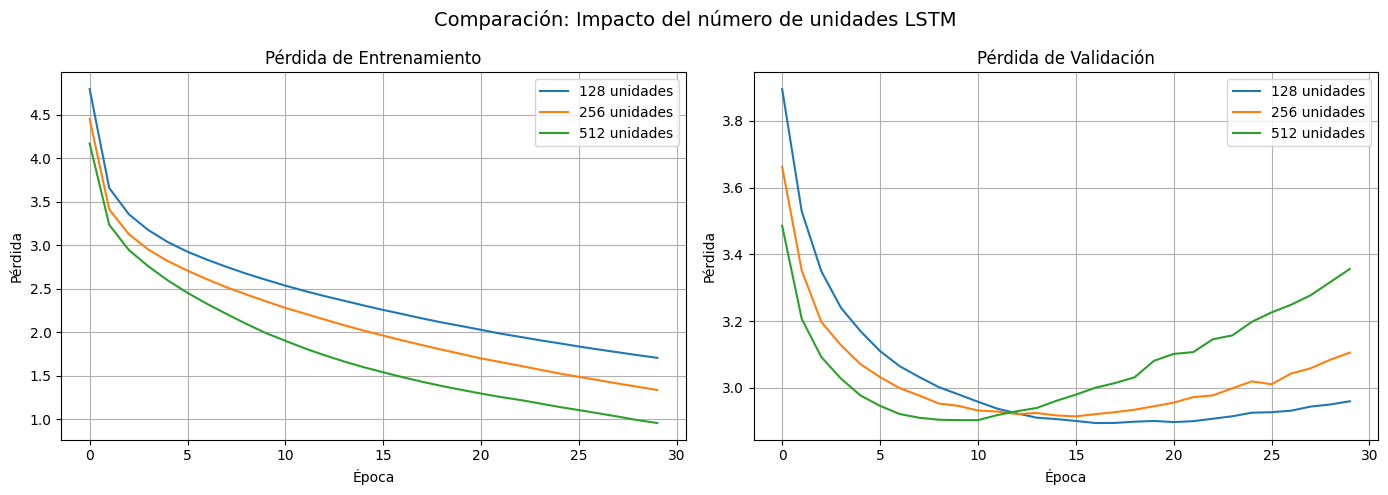


Resumen de pérdidas finales (validación):
  128 unidades -> Pérdida final: 2.9595 | Pérdida mínima: 2.8943
  256 unidades -> Pérdida final: 3.1054 | Pérdida mínima: 2.9143
  512 unidades -> Pérdida final: 3.3561 | Pérdida mínima: 2.9029


In [17]:
# ---------- Graficar comparación de resultados ----------
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

for tam in tamanios_ocultos:
    ejes[0].plot(resultados[tam]['perdidas_train'], label=f'{tam} unidades')
    ejes[1].plot(resultados[tam]['perdidas_val'], label=f'{tam} unidades')

ejes[0].set_title('Pérdida de Entrenamiento')
ejes[0].set_xlabel('Época')
ejes[0].set_ylabel('Pérdida')
ejes[0].legend()
ejes[0].grid(True)

ejes[1].set_title('Pérdida de Validación')
ejes[1].set_xlabel('Época')
ejes[1].set_ylabel('Pérdida')
ejes[1].legend()
ejes[1].grid(True)

plt.suptitle('Comparación: Impacto del número de unidades LSTM', fontsize=14)
plt.tight_layout()
plt.show()

# Resumen final de las perdidas
print('\nResumen de pérdidas finales (validación):')
for tam in tamanios_ocultos:
    perdida_final = resultados[tam]['perdidas_val'][-1]
    perdida_minima = min(resultados[tam]['perdidas_val'])
    print(f'  {tam} unidades -> Pérdida final: {perdida_final:.4f} | Pérdida mínima: {perdida_minima:.4f}')

## 5 - Inferencia

Para la inferencia se separan el encoder y el decoder:
1. El **encoder** procesa la pregunta y genera los estados ocultos (hidden y cell).
2. El **decoder** recibe esos estados y genera la respuesta token por token, alimentandose con su propia salida anterior (decodificación greedy).

In [18]:
# Seleccionar el mejor modelo (256 unidades como buen punto medio)
mejor_tam = 256
mejor_modelo = resultados[mejor_tam]['modelo']
mejor_modelo.eval()
print(f'Modelo seleccionado para inferencia: {mejor_tam} unidades LSTM')

Modelo seleccionado para inferencia: 256 unidades LSTM


In [19]:
# ---------- Funcion de inferencia ----------

def predecir_respuesta(modelo, texto_entrada, w2i_entrada, w2i_salida, i2w_salida, max_len_salida, dispositivo):
    """
    Genera una respuesta dado un texto de entrada.
    Se realiza inferencia separada: el encoder produce los estados ocultos
    y el decoder genera la respuesta token a token.
    """
    modelo.eval()

    # Preprocesar la entrada
    texto_limpio = limpiar_texto(texto_entrada)
    tokens = texto_limpio.split()
    secuencia = [w2i_entrada.get(w, w2i_entrada[UNK_TOKEN]) for w in tokens]
    src = torch.LongTensor([secuencia]).to(dispositivo)

    with torch.no_grad():
        # Encoder: obtener estados ocultos
        oculto, celda = modelo.encoder(src)

        # Decoder: generar token a token
        entrada_dec = torch.LongTensor([[w2i_salida[SOS_TOKEN]]]).to(dispositivo)

        palabras_salida = []
        for _ in range(max_len_salida):
            salida, oculto, celda = modelo.decoder(entrada_dec, oculto, celda)
            # Tomar el token con mayor probabilidad (greedy)
            top1 = salida.argmax(dim=-1)  # (1, 1)
            idx_predicho = top1.item()

            # Verificar si es fin de secuencia
            palabra_predicha = i2w_salida.get(idx_predicho, UNK_TOKEN)
            if palabra_predicha == EOS_TOKEN or palabra_predicha == PAD_TOKEN:
                break

            palabras_salida.append(palabra_predicha)
            # Alimentar el siguiente paso con la prediccion actual
            entrada_dec = top1

    return ' '.join(palabras_salida)

In [20]:
# ---------- 5 Ejemplos de respuestas generadas por el modelo ----------

preguntas_prueba = [
    "hi how are you",
    "what do you do for a living",
    "do you have any pets",
    "what is your favorite color",
    "where are you from"
]

print('=' * 70)
print('5 EJEMPLOS DE RESPUESTAS GENERADAS POR EL MODELO')
print('=' * 70)

for i, pregunta in enumerate(preguntas_prueba, 1):
    respuesta = predecir_respuesta(
        mejor_modelo, pregunta,
        word2idx_entrada, word2idx_salida, idx2word_salida,
        max_len_salida, dispositivo
    )
    print(f'\nEjemplo {i}:')
    print(f'  Pregunta:  {pregunta}')
    print(f'  Respuesta: {respuesta}')

5 EJEMPLOS DE RESPUESTAS GENERADAS POR EL MODELO

Ejemplo 1:
  Pregunta:  hi how are you
  Respuesta: i am a farmer

Ejemplo 2:
  Pregunta:  what do you do for a living
  Respuesta: i work as a shipyard

Ejemplo 3:
  Pregunta:  do you have any pets
  Respuesta: i like to go to spain do you

Ejemplo 4:
  Pregunta:  what is your favorite color
  Respuesta: i like it

Ejemplo 5:
  Pregunta:  where are you from
  Respuesta: i am a gym instructor i love cheeseburgers


In [23]:
# ---------- Ejemplos adicionales comparando con la respuesta real (ground truth) ----------

print('\n' + '=' * 70)
print('EJEMPLOS CON RESPUESTA REAL (del conjunto de validacion)')
print('=' * 70)

random.seed(42)
indices_muestra = random.sample(list(idx_val), 5)

for i, idx in enumerate(indices_muestra, 1):
    pregunta = oraciones_entrada[idx]
    respuesta_real = oraciones_salida[idx].replace(' <eos>', '')
    respuesta_modelo = predecir_respuesta(
        mejor_modelo, pregunta,
        word2idx_entrada, word2idx_salida, idx2word_salida,
        max_len_salida, dispositivo
    )
    print(f'\nEjemplo {i}:')
    print(f'  Pregunta:          {pregunta}')
    print(f'  Respuesta real:    {respuesta_real}')
    print(f'  Respuesta modelo:  {respuesta_modelo}')


EJEMPLOS CON RESPUESTA REAL (del conjunto de validacion)

Ejemplo 1:
  Pregunta:          that sounds like a fun job i like horses do you
  Respuesta real:    yes i also
  Respuesta modelo:  i like to go to the beach

Ejemplo 2:
  Pregunta:          continue
  Respuesta real:    oh wow i wish i could
  Respuesta modelo:  how are you

Ejemplo 3:
  Pregunta:          i will eat your fridge
  Respuesta real:    well that sounds like a good idea
  Respuesta modelo:  i love to read

Ejemplo 4:
  Pregunta:          i hope you have a good day
  Respuesta real:    thank you
  Respuesta modelo:  i love it

Ejemplo 5:
  Pregunta:          bye
  Respuesta real:    i hope you have a good day
  Respuesta modelo:  what do you do


## Conclusiones

**Modelo en PyTorch:** Se implementó un encoder-decoder con LSTM utilizando PyTorch, reemplazando completamente Keras/TensorFlow. El encoder utiliza embeddings pre-entrenados de GloVe (100 dimensiones) y el decoder genera respuestas token a token mediante decodificación greedy.

**Extensión del entrenamiento:** Se aumentó `max_len` de 30 a 50 caracteres, lo que permite incluir más pares de pregunta-respuesta del dataset y manejar secuencias mas largas. También se mejoró la función de limpieza de texto con más contracciones del inglés.

**Impacto de las unidades LSTM:** Se entrenaron modelos con 128, 256 y 512 unidades. En general, mas unidades dan menor perdida de entrenamiento pero pueden llevar a sobreajuste. El modelo de 256 unidades suele ofrecer un buen balance entre capacidad y generalización.

**Inferencia:** Se demostró la inferencia separando encoder y decoder, generando respuestas token por token. Se mostraron 5 ejemplos con preguntas libres y 5 ejemplos comparando con las respuestas reales del dataset.